In [8]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.version.cuda)   

True
12.1


In [9]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

# Check if CUDA is available and set device accordingly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define a simple Graph Neural Network (GCN)
class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(3, 16)  # Input: 3 features, Output: 16 hidden channels
        self.conv2 = GCNConv(16, 1)  # Output layer: 1 feature (prediction)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # Apply first convolution layer with ReLU activation
        x = F.relu(self.conv1(x, edge_index))
        # Apply second convolution layer
        x = self.conv2(x, edge_index)
        return x

# Create a simple graph data
# Suppose we have 5 nodes and 4 edges
edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # 2xE (E = number of edges)
x = torch.tensor([[1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 6], [5, 6, 7]], dtype=torch.float)  # Node features, 5x3

# Create the graph data object
data = Data(x=x, edge_index=edge_index)

# Move the data to the GPU if available
data = data.to(device)

# Initialize the GCN model and move it to the GPU if available
model = GCN().to(device)

# Forward pass through the GCN
output = model(data)

# Print the output
print("GNN Output:")
print(output)

ImportError: cannot import name 'is_compiling' from 'torch_geometric' (unknown location)

In [10]:
python -c "import torch; print(torch.__version__)"

SyntaxError: invalid syntax (609037931.py, line 1)

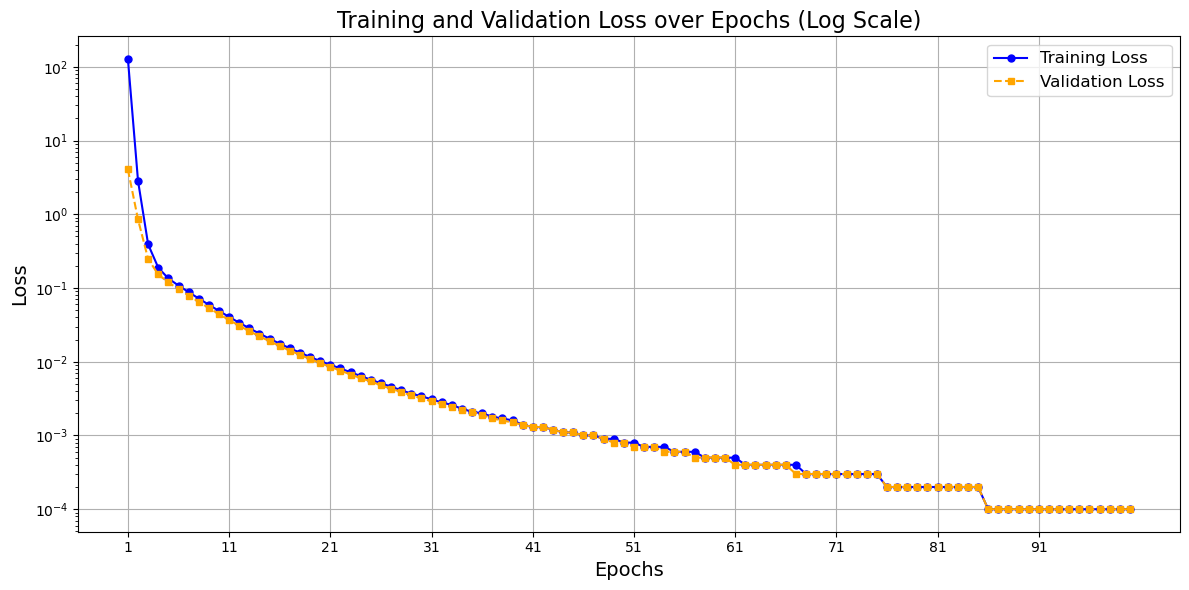

In [19]:
import matplotlib.pyplot as plt

# エポックごとの損失をリストに格納
epochs = list(range(1, 101))  # 1から100までのエポック
train_losses = [
    128.1583, 2.8378, 0.3901, 0.1886, 0.1346, 
    0.1080, 0.0879, 0.0720, 0.0592, 0.0489, 
    0.0405, 0.0338, 0.0284, 0.0241, 0.0205, 
    0.0176, 0.0152, 0.0133, 0.0116, 0.0102, 
    0.0091, 0.0081, 0.0072, 0.0064, 0.0057, 
    0.0051, 0.0046, 0.0041, 0.0037, 0.0034, 
    0.0031, 0.0028, 0.0026, 0.0023, 0.0021, 
    0.0020, 0.0018, 0.0017, 0.0016, 0.0014, 
    0.0013, 0.0013, 0.0012, 0.0011, 0.0011, 
    0.0010, 0.0010, 0.0009, 0.0009, 0.0008, 
    0.0008, 0.0007, 0.0007, 0.0007, 0.0006, 
    0.0006, 0.0006, 0.0005, 0.0005, 0.0005, 
    0.0005, 0.0004, 0.0004, 0.0004, 0.0004, 
    0.0004, 0.0004, 0.0003, 0.0003, 0.0003, 
    0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001
]
val_losses = [
    4.0572, 0.8504, 0.2471, 0.1525, 0.1190, 
    0.0969, 0.0791, 0.0649, 0.0535, 0.0443, 
    0.0368, 0.0308, 0.0260, 0.0221, 0.0190, 
    0.0163, 0.0142, 0.0124, 0.0109, 0.0096, 
    0.0085, 0.0076, 0.0067, 0.0060, 0.0054, 
    0.0048, 0.0043, 0.0039, 0.0035, 0.0032, 
    0.0029, 0.0027, 0.0024, 0.0022, 0.0021, 
    0.0019, 0.0017, 0.0016, 0.0015, 0.0014, 
    0.0013, 0.0013, 0.0012, 0.0011, 0.0011, 
    0.0010, 0.0010, 0.0009, 0.0008, 0.0008, 
    0.0007, 0.0007, 0.0007, 0.0006, 0.0006, 
    0.0006, 0.0005, 0.0005, 0.0005, 0.0005, 
    0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 
    0.0004, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001
]

plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o', linestyle='-', markersize=5)
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='s', linestyle='--', markersize=5)
plt.title('Training and Validation Loss over Epochs (Log Scale)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.yscale('log')  # Y軸を対数スケールに設定
plt.xticks(range(1, 101, 10), fontsize=10)  # 10刻みの目盛り
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()  # レイアウトを自動調整
plt.show()

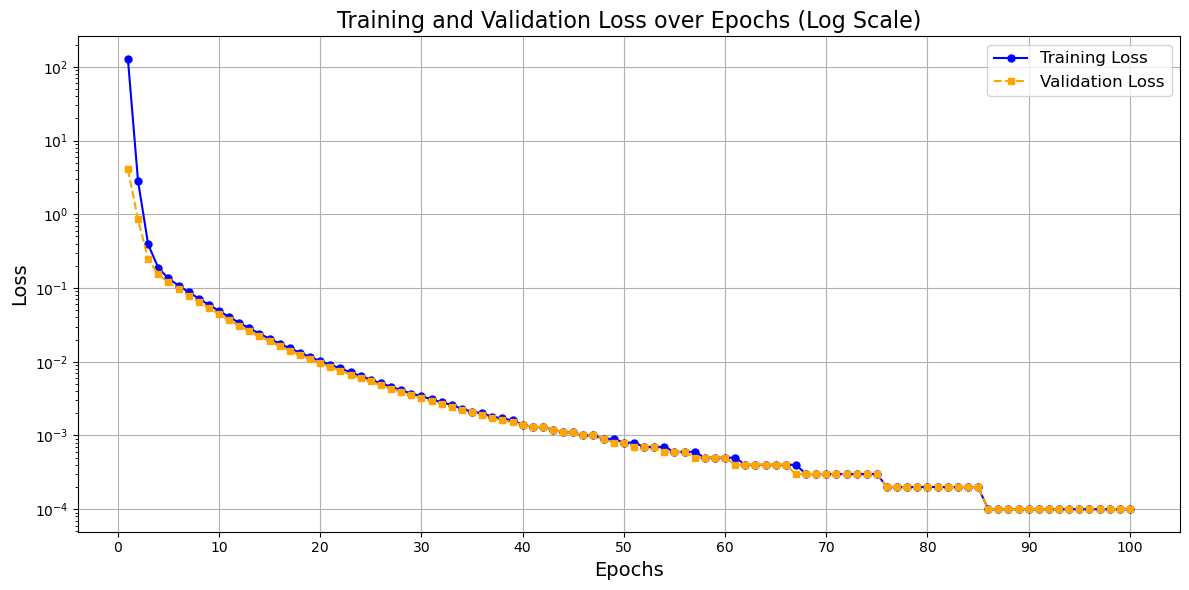

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o', linestyle='-', markersize=5)
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='s', linestyle='--', markersize=5)
plt.title('Training and Validation Loss over Epochs (Log Scale)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.yscale('log')  # Y軸を対数スケールに設定
plt.xticks(range(0, 101, 10), fontsize=10)  # 10刻みの目盛り
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()  # レイアウトを自動調整
plt.show()

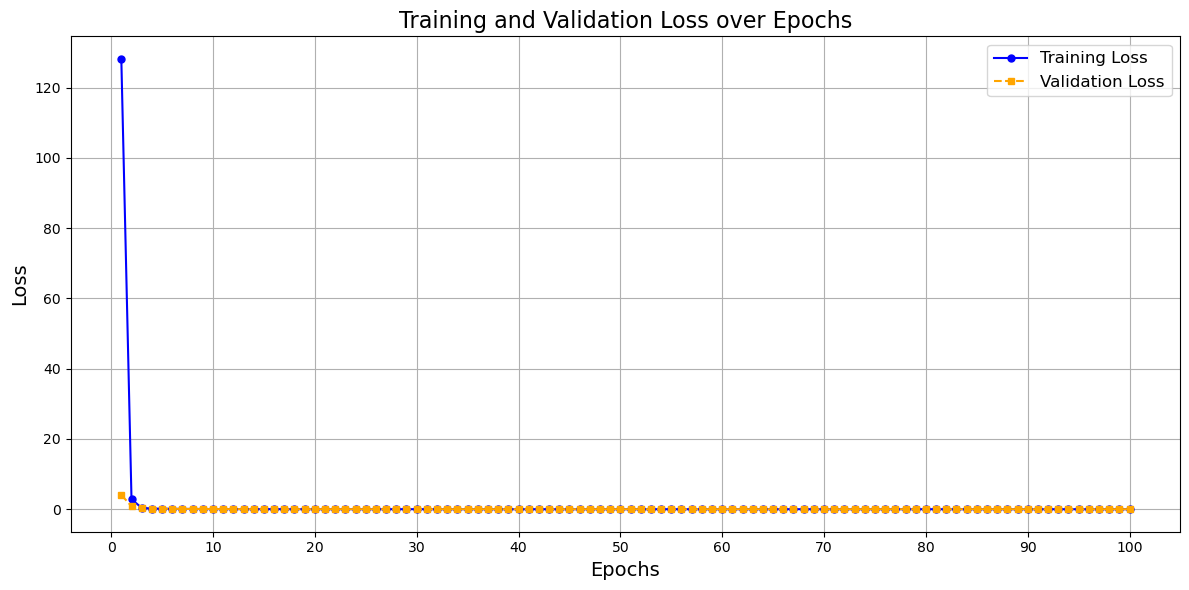

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o', linestyle='-', markersize=5)
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='s', linestyle='--', markersize=5)
plt.title('Training and Validation Loss over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(range(0, 101, 10), fontsize=10)  # 10刻みの目盛り
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()  # レイアウトを自動調整
plt.show()

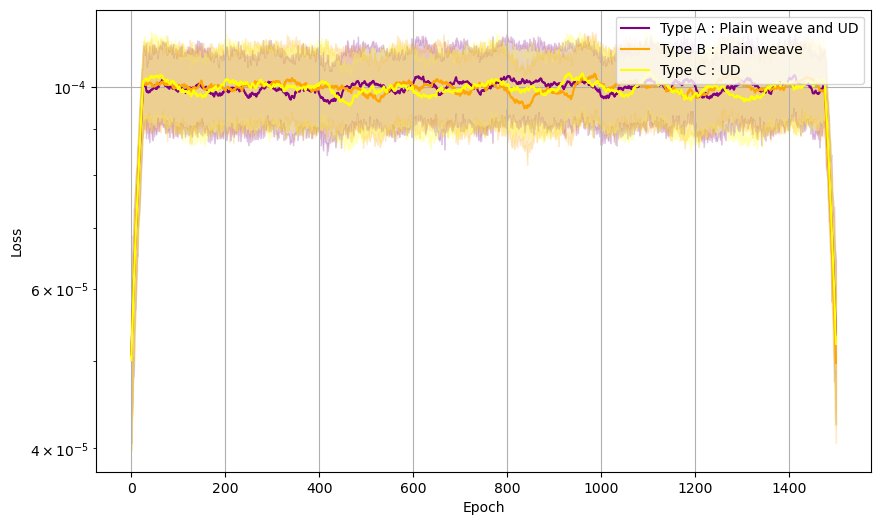

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# データのサンプル (Type A, Type B, Type C)
x = np.linspace(0, 1500, 1500)
y_a = np.random.normal(0.0001, 0.00001, 1500)
y_b = np.random.normal(0.0001, 0.00001, 1500)
y_c = np.random.normal(0.0001, 0.00001, 1500)

# 平滑化 (移動平均)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

# 標準偏差
y_a_std = y_a * 0.1
y_b_std = y_b * 0.1
y_c_std = y_c * 0.1

# グラフのプロット
plt.figure(figsize=(10, 6))

# Type A
plt.plot(x, smooth(y_a, 50), color='purple', label='Type A : Plain weave and UD')
plt.fill_between(x, smooth(y_a, 50) - y_a_std, smooth(y_a, 50) + y_a_std, color='purple', alpha=0.2)

# Type B
plt.plot(x, smooth(y_b, 50), color='orange', label='Type B : Plain weave')
plt.fill_between(x, smooth(y_b, 50) - y_b_std, smooth(y_b, 50) + y_b_std, color='orange', alpha=0.2)

# Type C
plt.plot(x, smooth(y_c, 50), color='yellow', label='Type C : UD')
plt.fill_between(x, smooth(y_c, 50) - y_c_std, smooth(y_c, 50) + y_c_std, color='yellow', alpha=0.2)

# 対数スケール
plt.yscale('log')

# ラベルと凡例
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# グリッドの追加
plt.grid(True)

# プロット表示
plt.show()


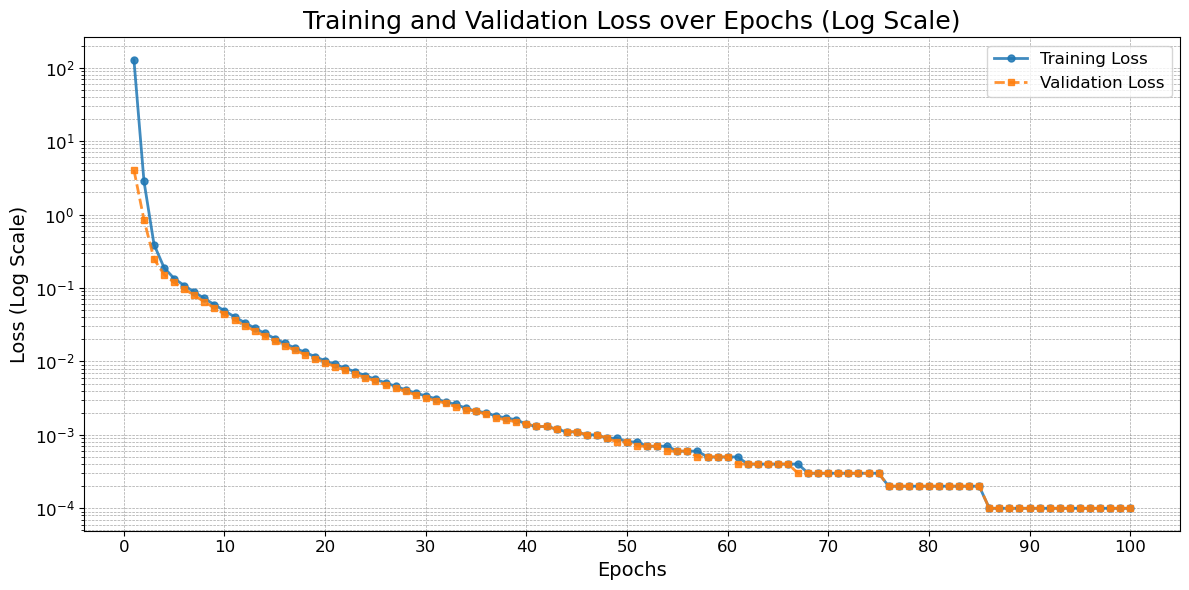

In [26]:
import matplotlib.pyplot as plt

# エポックごとの損失をリストに格納 (データは変わらず)
epochs = list(range(1, 101))  
train_losses = [
    128.1583, 2.8378, 0.3901, 0.1886, 0.1346, 
    0.1080, 0.0879, 0.0720, 0.0592, 0.0489, 
    0.0405, 0.0338, 0.0284, 0.0241, 0.0205, 
    0.0176, 0.0152, 0.0133, 0.0116, 0.0102, 
    0.0091, 0.0081, 0.0072, 0.0064, 0.0057, 
    0.0051, 0.0046, 0.0041, 0.0037, 0.0034, 
    0.0031, 0.0028, 0.0026, 0.0023, 0.0021, 
    0.0020, 0.0018, 0.0017, 0.0016, 0.0014, 
    0.0013, 0.0013, 0.0012, 0.0011, 0.0011, 
    0.0010, 0.0010, 0.0009, 0.0009, 0.0008, 
    0.0008, 0.0007, 0.0007, 0.0007, 0.0006, 
    0.0006, 0.0006, 0.0005, 0.0005, 0.0005, 
    0.0005, 0.0004, 0.0004, 0.0004, 0.0004, 
    0.0004, 0.0004, 0.0003, 0.0003, 0.0003, 
    0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001
]
val_losses = [
    4.0572, 0.8504, 0.2471, 0.1525, 0.1190, 
    0.0969, 0.0791, 0.0649, 0.0535, 0.0443, 
    0.0368, 0.0308, 0.0260, 0.0221, 0.0190, 
    0.0163, 0.0142, 0.0124, 0.0109, 0.0096, 
    0.0085, 0.0076, 0.0067, 0.0060, 0.0054, 
    0.0048, 0.0043, 0.0039, 0.0035, 0.0032, 
    0.0029, 0.0027, 0.0024, 0.0022, 0.0021, 
    0.0019, 0.0017, 0.0016, 0.0015, 0.0014, 
    0.0013, 0.0013, 0.0012, 0.0011, 0.0011, 
    0.0010, 0.0010, 0.0009, 0.0008, 0.0008, 
    0.0007, 0.0007, 0.0007, 0.0006, 0.0006, 
    0.0006, 0.0005, 0.0005, 0.0005, 0.0005, 
    0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 
    0.0004, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001
]

# グラフの描画設定
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', marker='o', linestyle='-', markersize=5, alpha=0.85, lw=2)
plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', marker='s', linestyle='--', markersize=5, alpha=0.85, lw=2)

# グラフのタイトル、ラベル設定
plt.title('Training and Validation Loss over Epochs (Log Scale)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (Log Scale)', fontsize=14)

# 対数スケールと目盛りの調整
plt.yscale('log')
plt.xticks(range(0, 101, 10), fontsize=12)
plt.yticks(fontsize=12)

# グリッドと間隔の設定 (透明度の調整)
plt.grid(True, which="both", ls="--", lw=0.5, color='gray', alpha=0.7)

# 凡例の追加と位置調整
plt.legend(fontsize=12, loc='upper right')

# レイアウト調整
plt.tight_layout()

# グラフの表示
plt.show()


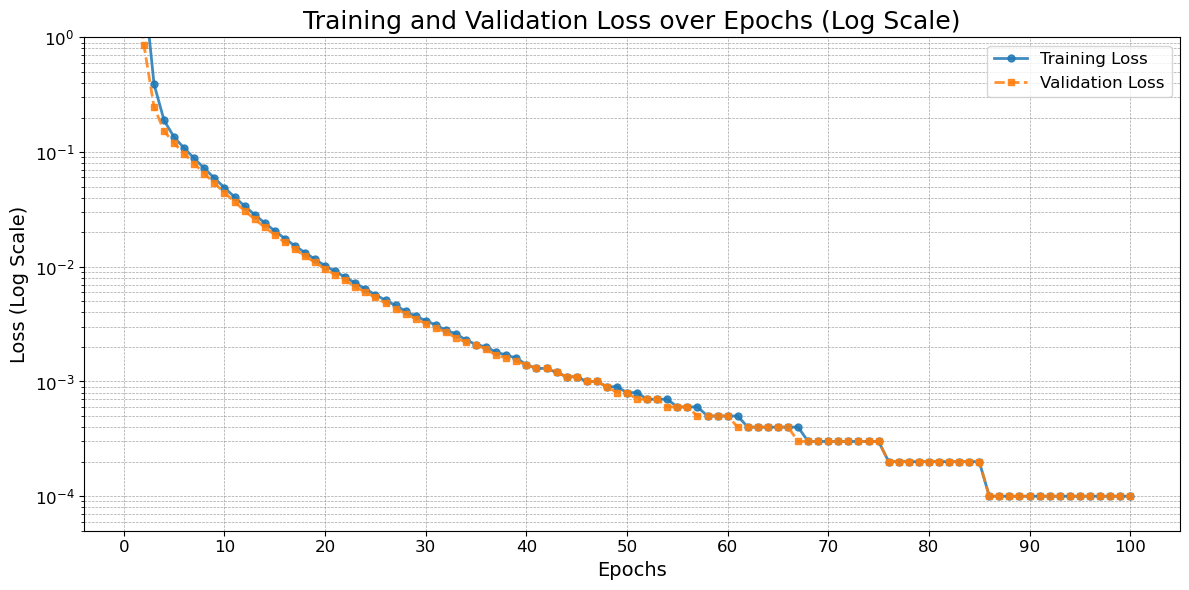

In [28]:
import matplotlib.pyplot as plt

# エポックごとの損失をリストに格納 (データは変わらず)
epochs = list(range(1, 101))  
train_losses = [
    128.1583, 2.8378, 0.3901, 0.1886, 0.1346, 
    0.1080, 0.0879, 0.0720, 0.0592, 0.0489, 
    0.0405, 0.0338, 0.0284, 0.0241, 0.0205, 
    0.0176, 0.0152, 0.0133, 0.0116, 0.0102, 
    0.0091, 0.0081, 0.0072, 0.0064, 0.0057, 
    0.0051, 0.0046, 0.0041, 0.0037, 0.0034, 
    0.0031, 0.0028, 0.0026, 0.0023, 0.0021, 
    0.0020, 0.0018, 0.0017, 0.0016, 0.0014, 
    0.0013, 0.0013, 0.0012, 0.0011, 0.0011, 
    0.0010, 0.0010, 0.0009, 0.0009, 0.0008, 
    0.0008, 0.0007, 0.0007, 0.0007, 0.0006, 
    0.0006, 0.0006, 0.0005, 0.0005, 0.0005, 
    0.0005, 0.0004, 0.0004, 0.0004, 0.0004, 
    0.0004, 0.0004, 0.0003, 0.0003, 0.0003, 
    0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001
]
val_losses = [
    4.0572, 0.8504, 0.2471, 0.1525, 0.1190, 
    0.0969, 0.0791, 0.0649, 0.0535, 0.0443, 
    0.0368, 0.0308, 0.0260, 0.0221, 0.0190, 
    0.0163, 0.0142, 0.0124, 0.0109, 0.0096, 
    0.0085, 0.0076, 0.0067, 0.0060, 0.0054, 
    0.0048, 0.0043, 0.0039, 0.0035, 0.0032, 
    0.0029, 0.0027, 0.0024, 0.0022, 0.0021, 
    0.0019, 0.0017, 0.0016, 0.0015, 0.0014, 
    0.0013, 0.0013, 0.0012, 0.0011, 0.0011, 
    0.0010, 0.0010, 0.0009, 0.0008, 0.0008, 
    0.0007, 0.0007, 0.0007, 0.0006, 0.0006, 
    0.0006, 0.0005, 0.0005, 0.0005, 0.0005, 
    0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 
    0.0004, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
    0.0001, 0.0001, 0.0001, 0.0001, 0.0001
]
# グラフの描画設定
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', marker='o', linestyle='-', markersize=5, alpha=0.85, lw=2)
plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', marker='s', linestyle='--', markersize=5, alpha=0.85, lw=2)

# グラフのタイトル、ラベル設定
plt.title('Training and Validation Loss over Epochs (Log Scale)', fontsize=18)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (Log Scale)', fontsize=14)

# 対数スケールと縦軸の上限設定
plt.yscale('log')
plt.ylim(5e-5, 10**0)  # 縦軸の範囲を1e-4から10^0に設定

# x軸の目盛り調整
plt.xticks(range(0, 101, 10), fontsize=12)
plt.yticks(fontsize=12)

# グリッドと間隔の設定 (透明度の調整)
plt.grid(True, which="both", ls="--", lw=0.5, color='gray', alpha=0.7)

# 凡例の追加と位置調整
plt.legend(fontsize=12, loc='upper right')

# レイアウト調整
plt.tight_layout()

# グラフの表示
plt.show()